In [1]:
from pathlib import Path
import polars as pl

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_ROOT = PROJECT_ROOT / "tennis_data"
data_path = DATA_ROOT / "Data"

In [3]:
# Load Home Team and Away Team datasets

home_team = pl.read_parquet(data_path / "home_team.parquet")
away_team = pl.read_parquet(data_path / "away_team.parquet")

print("Home Team shape:", home_team.shape)
print("Away Team shape:", away_team.shape)

Home Team shape: (25610, 19)
Away Team shape: (24203, 19)


In [4]:
# Check the distribution of values in the plays column for Home and Away players

print("Home Team:")
print(
    home_team
    .group_by("plays")
    .len()
    .sort("len", descending=True)
)

print("\nAway Team:")
print(
    away_team
    .group_by("plays")
    .len()
    .sort("len", descending=True)
)

Home Team:
shape: (3, 2)
┌──────────────┬───────┐
│ plays        ┆ len   │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ null         ┆ 13126 │
│ right-handed ┆ 11106 │
│ left-handed  ┆ 1378  │
└──────────────┴───────┘

Away Team:
shape: (3, 2)
┌──────────────┬───────┐
│ plays        ┆ len   │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ null         ┆ 12244 │
│ right-handed ┆ 10494 │
│ left-handed  ┆ 1465  │
└──────────────┴───────┘


In [7]:
# Combine Home and Away players and keep unique players

players = pl.concat([
    home_team.select(["player_id", "plays"]),
    away_team.select(["player_id", "plays"])
])

unique_players = (
    players
    .filter(pl.col("player_id").is_not_null())
    .unique(subset="player_id", keep="first")
)

print("Total unique players:", unique_players.height)

unique_players.group_by("plays").len().sort("len", descending=True)

Total unique players: 2644


plays,len
str,u32
null,1498
"""right-handed""",1013
"""left-handed""",133


In [9]:
# Calculate handedness distribution and percentages

handedness_distribution = (
    unique_players
    .filter(pl.col("plays").is_not_null())
    .group_by("plays")
    .len()
    .with_columns(
        (pl.col("len") / pl.col("len").sum() * 100)
        .round(2)
        .alias("percentage")
    )
    .sort("len", descending=True)
)

handedness_distribution

plays,len,percentage
str,u32,f64
"""right-handed""",1013,88.39
"""left-handed""",133,11.61


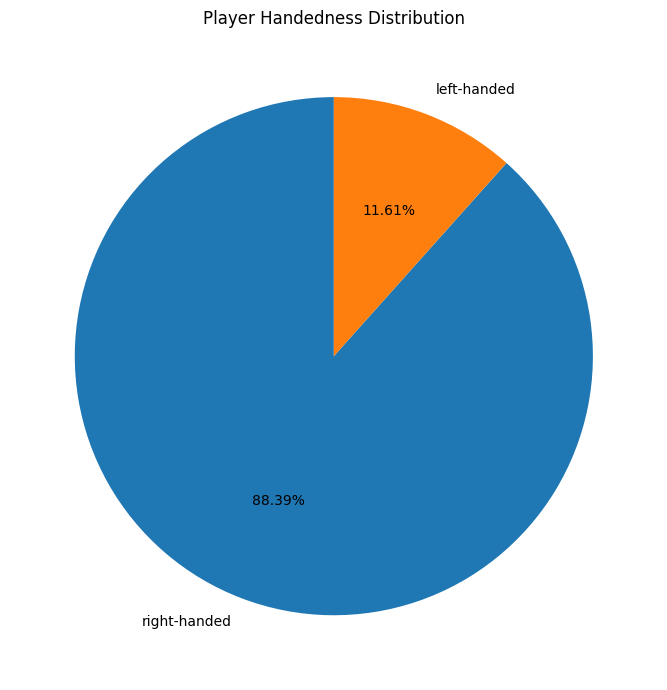

In [10]:
# Visualize handedness distribution

import matplotlib.pyplot as plt

labels = handedness_distribution["plays"].to_list()
sizes = handedness_distribution["percentage"].to_list()

plt.figure(figsize=(7, 7))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Player Handedness Distribution")
plt.tight_layout()
plt.show()